In [4]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==============================
# LOAD DATASET
# ==============================

file_path = "heart_2020_cleaned.csv"

df = pd.read_csv(file_path)

# Display first five rows
print("First 5 rows of the dataset:")
display(df.head())

# Dataset shape
print("Dataset shape:")
print(df.shape)

First 5 rows of the dataset:


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No


Dataset shape:
(319795, 18)


In [5]:
# ==============================
# BASIC DATASET INFORMATION
# ==============================

print("Dataset information:")
df.info()

print("\nColumn names:")
print(df.columns.tolist())

print("\nStatistical summary:")
display(df.describe())

print("\nCategorical column summary:")
display(df.describe(include="object"))

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  int64  
 6   MentalHealth      319795 non-null  int64  
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  int64  
 15  Asthma            319795 non-null  object 
 16 

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000



Categorical column summary:


,HeartDisease,Smoking,AlcoholDrinking,Stroke,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,Asthma,KidneyDisease,SkinCancer
count,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795
unique,2,2,2,2,2,2,13,6,4,2,5,2,2,2
top,No,No,No,No,No,Female,65-69,White,No,Yes,Very good,No,No,No
freq,292422,187887,298018,307726,275385,167805,34151,245212,269653,247957,113858,276923,308016,289976


In [6]:
# ==============================
# CHECK NULL VALUES
# ==============================

print("Missing values in each column:")
null_values = df.isnull().sum()
print(null_values)

print("\nTotal missing values:")
print(df.isnull().sum().sum())

# ==============================
# CHECK DUPLICATES
# ==============================

duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:")
print(duplicate_count)

Missing values in each column:
HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

Total missing values:
0

Number of duplicate rows:
18078


In [7]:
# ==============================
# CLEAN COLUMN NAMES
# ==============================

df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")

print("Updated column names:")
print(df.columns.tolist())

Updated column names:
['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer']


In [8]:
# ==============================
# REMOVE DUPLICATES
# ==============================

print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Shape before removing duplicates: (319795, 18)
Shape after removing duplicates: (301717, 18)
Remaining duplicate rows: 0


In [9]:
# ==============================
# TARGET COLUMN DISTRIBUTION
# ==============================

target_col = "HeartDisease"

print("Target column value counts:")
print(df[target_col].value_counts())

print("\nTarget column percentage:")
print(df[target_col].value_counts(normalize=True) * 100)

Target column value counts:
HeartDisease
No     274456
Yes     27261
Name: count, dtype: int64

Target column percentage:
HeartDisease
No     90.964712
Yes     9.035288
Name: proportion, dtype: float64


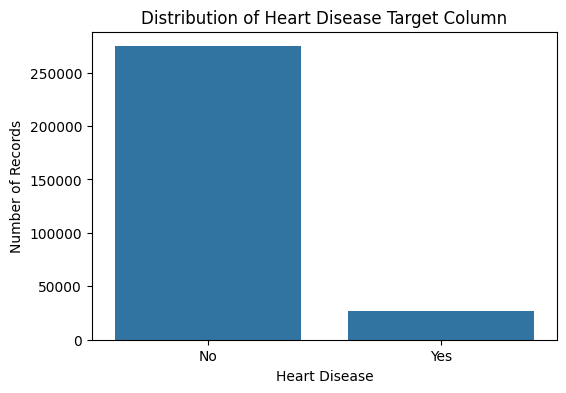

In [10]:
# ==============================
# TARGET DISTRIBUTION PLOT
# ==============================

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="HeartDisease")
plt.title("Distribution of Heart Disease Target Column")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Records")
plt.show()